# **Licenciatura em Ciências da Computação**

### Aprendizagem Computacional 25/26

Árvores, SVM, Gradient Boosting, Hyperparameter Search, Bias/Variance, Confusion Matrix, ROC/PR-AUC, Threshold Tuning

It follows a **clean supervised learning workflow**:

1. Split data into **train** and **test**
2. Use the **training set only** for model comparison and hyperparameter search
3. Choose the best model using cross-validation
4. Choose the classification **threshold using out-of-fold predictions on the training set**
5. Fit the final model on the full training set
6. Evaluate **once** on the untouched test set

Main topics:
- Decision Trees
- SVM
- Gradient Boosting
- Bias / Variance
- Hyperparameter Search
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Threshold Tuning

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
)

## Utility functions
A couple of small helper functions.

In [2]:
def plot_confusion_matrix_simple(cm, labels=("Negative", "Positive")):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


def summarize_grid(grid, model_name):
    row = {
        "model": model_name,
        "best_params": grid.best_params_,
        "best_cv_accuracy": round(grid.best_score_, 4),
    }
    return row

# 1) Real dataset

We will use the **Breast Cancer Wisconsin** dataset from scikit-learn.

This is a binary classification problem, which is perfect for:
- confusion matrix
- ROC curve
- PR curve
- threshold tuning

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())
print(data.target_names)
X.head()

Dataset shape: (569, 30)
Class distribution:
target
0    212
1    357
Name: count, dtype: int64
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


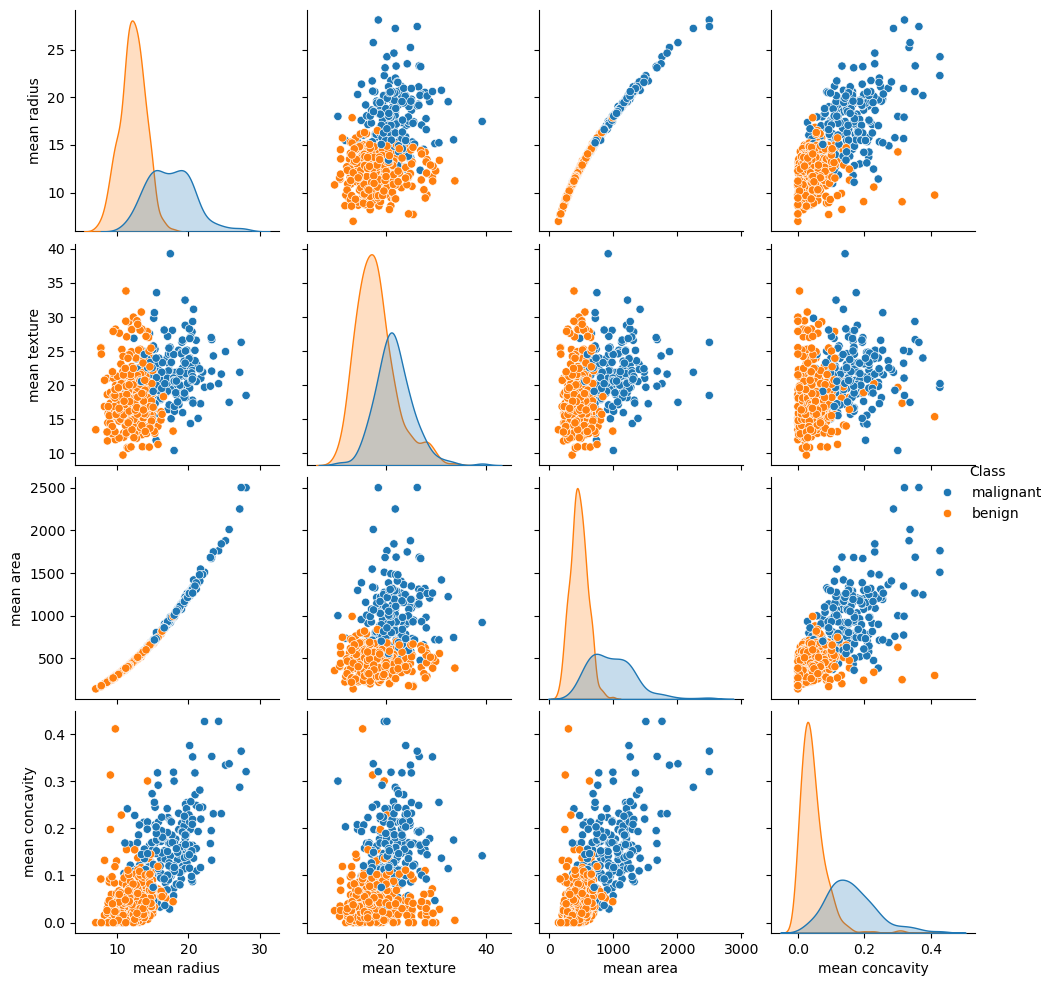

In [ ]:
df = X.copy()
df["target"] = y

g = sns.pairplot(
    df,
    vars=["mean radius", "mean texture", "mean area", "mean concavity"],
    hue="target"
)

g._legend.set_title("Class")

g._legend.texts[0].set_text("malignant")
g._legend.texts[1].set_text("benign")
plt.show()

## Train / test split

The test set will stay untouched until the very end.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (455, 30)
Test shape:  (114, 30)


# 2) Bias / Variance intuition with Decision Trees


A shallow tree may **underfit**.  
A very deep tree may **overfit**.

We will vary `max_depth` and compare:
- training accuracy
- cross-validation accuracy

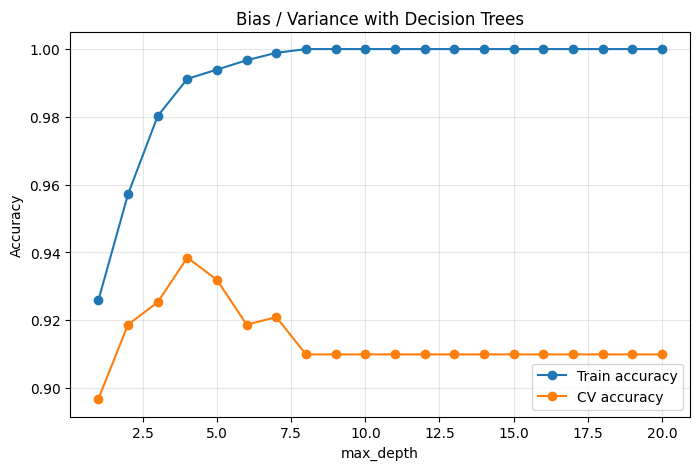

In [ ]:
depths = range(1, 21)

train_scores = []
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)

    scores = cross_validate(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    train_scores.append(scores["train_score"].mean())
    cv_scores.append(scores["test_score"].mean())

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, cv_scores, marker="o", label="CV accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Bias / Variance with Decision Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

Typical pattern when increasing model complexity (e.g., tree depth):

*   **Low depth**: both training and CV scores are low → the model is too simple and cannot capture the underlying pattern (underfitting / high bias).

*   **Moderate depth**: both scores improve → the model becomes expressive enough to learn useful structure in the data.

*   **Very high depth**: training score continues to increase while the CV score stops improving or starts decreasing → the model begins to memorize the training data (overfitting / high variance).

This behaviour illustrates the bias–variance tradeoff:

*   High bias models are too simple and underfit the data.

*   High variance models are too complex and overfit the training data.

The goal is to find a balance where the model is complex enough to capture the signal but still generalizes well to unseen data.



# 3) SVM intuition with a toy dataset

On real datasets, SVM decision boundaries are hard to visualize.

So we first use a simple 2D dataset to build intuition for:
- `C`
- `gamma`
- smooth vs wiggly decision boundaries

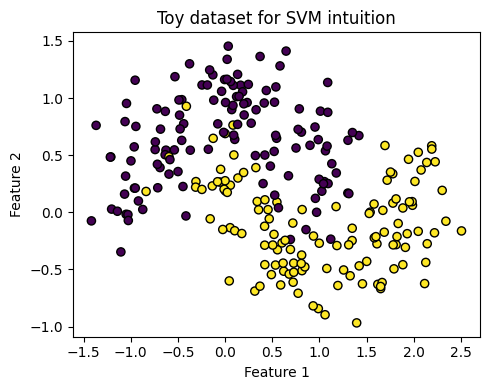

In [ ]:
X_toy, y_toy = make_moons(n_samples=250, noise=0.25, random_state=42)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, edgecolor="k", s=35)
ax.set_title("Toy dataset for SVM intuition")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

## Visual effect of `C` and `gamma`

Useful intuition:
- `C` controls how strict the model is with training errors
- `gamma` controls how local and flexible the boundary becomes

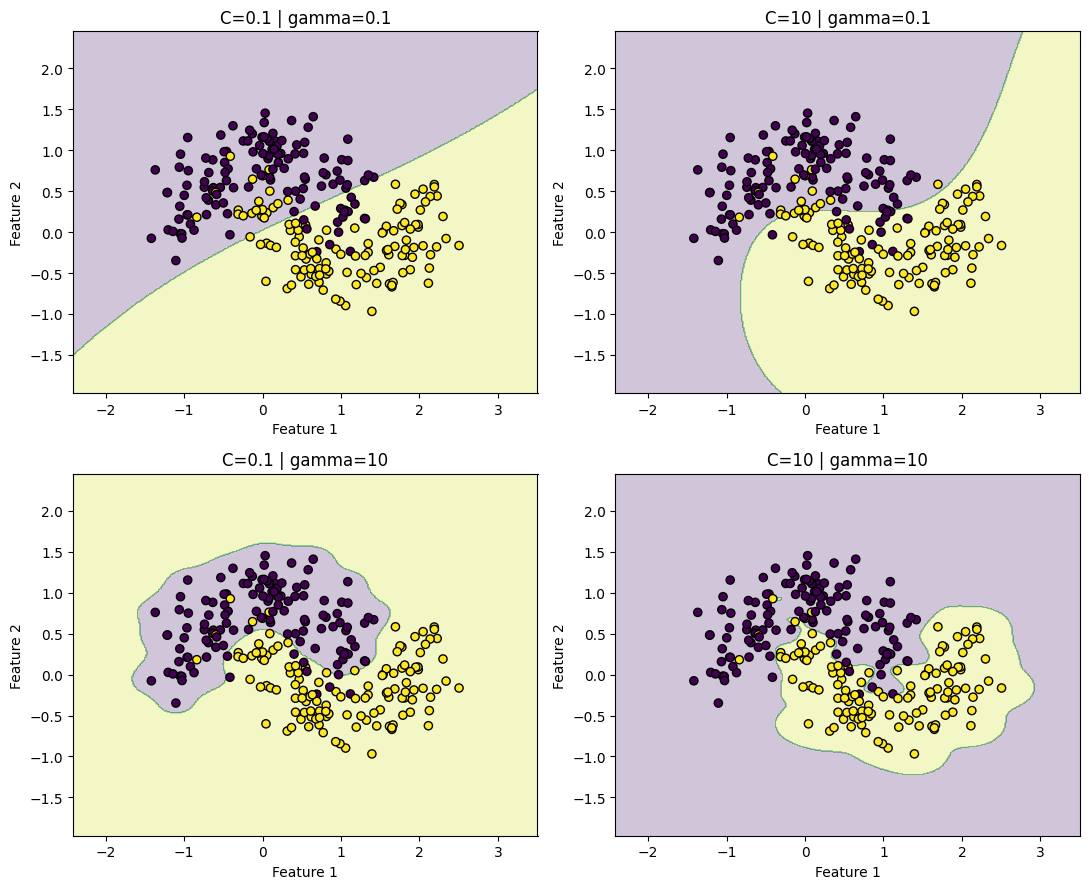

In [ ]:
svm_configs = [
    {"C": 0.1, "gamma": 0.1},
    {"C": 10,  "gamma": 0.1},
    {"C": 0.1, "gamma": 10},
    {"C": 10,  "gamma": 10},
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, cfg in zip(axes, svm_configs):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=cfg["C"], gamma=cfg["gamma"]))  #RBF -> polynomial kernel → non-linear boundary
    ])
    model.fit(X_toy, y_toy)
    plot_decision_boundary(
        model,
        X_toy,
        y_toy,
        ax,
        title=f"C={cfg['C']} | gamma={cfg['gamma']}"
    )

plt.tight_layout()
plt.show()

### Interpretation
Some general trends:
- low `C` usually gives a smoother boundary
- high `gamma` can make the boundary much more complex
- too much complexity can fit the training data too closely

i.e.

Gamma

Small gamma → points influence a large region → smoother boundary

Large gamma → points influence only nearby space → very wiggly boundary

C

Small C → allows mistakes → smoother boundary

Large C → tries to classify everything → uses more complexity



# 4) Compare three models on the training set

We now move back to the real dataset.

We will compare:
- Decision Tree
- SVM
- Gradient Boosting

Important:
- comparison is done using **cross-validation on the training set only**
- the test set is still untouched

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

comparison_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc"],
        n_jobs=-1
    )

    comparison_rows.append({
        "model": name,
        "mean_cv_accuracy": scores["test_accuracy"].mean(),
        "std_cv_accuracy": scores["test_accuracy"].std(),
        "mean_cv_roc_auc": scores["test_roc_auc"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("mean_cv_accuracy", ascending=False)
comparison_df

,model,mean_cv_accuracy,std_cv_accuracy,mean_cv_roc_auc
1,SVM,0.969231,0.014579,0.995562
2,Gradient Boosting,0.951648,0.014906,0.991950
0,Decision Tree,0.916484,0.017855,0.917905


**Do not choose a model based only on one train/test split.**  
Use cross-validation on the training set.

# 5) Hyperparameter search

Now we tune each model using **GridSearchCV** on the training set only.

In [ ]:
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    param_grid={
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [1, 2, 3],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [1, 2, 3],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
tuned_summary = pd.DataFrame([
    summarize_grid(tree_grid, "Decision Tree"),
    summarize_grid(svm_grid, "SVM"),
    summarize_grid(gb_grid, "Gradient Boosting"),
]).sort_values("best_cv_accuracy", ascending=False)

tuned_summary

,model,best_params,best_cv_accuracy
1,SVM,"{'svm__C': 10, 'svm__gamma': 0.01}",0.9758
2,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",0.9758
0,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",0.9385


## Visualizing the SVM search space

It simply evaluates many parameter combinations and compares their cross-validation scores.

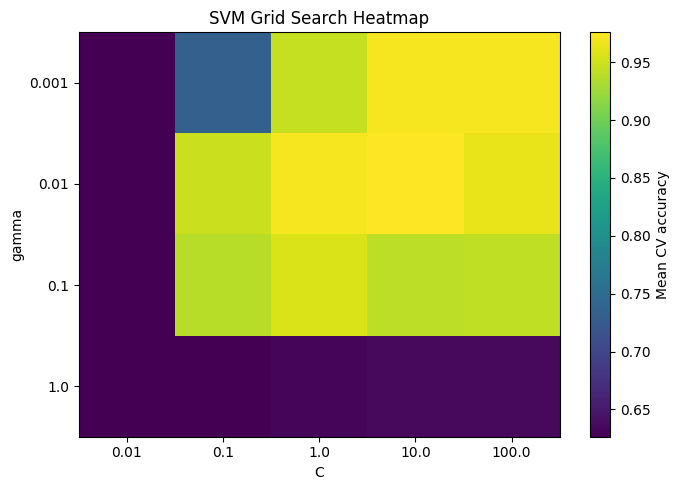

In [ ]:
svm_results = pd.DataFrame(svm_grid.cv_results_)

heatmap_data = svm_results.pivot_table(
    values="mean_test_score",
    index="param_svm__gamma",
    columns="param_svm__C"
)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean CV accuracy")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("SVM Grid Search Heatmap")
plt.tight_layout()
plt.show()

# 6) Select the best tuned model

We will select the model with the highest cross-validation accuracy on the training set.

In [ ]:
all_grids = {
    "Decision Tree": tree_grid,
    "SVM": svm_grid,
    "Gradient Boosting": gb_grid,
}

best_model_name = max(all_grids, key=lambda name: all_grids[name].best_score_)
best_grid = all_grids[best_model_name]

print("Best model:", best_model_name)
print("Best CV accuracy:", round(best_grid.best_score_, 4))
print("Best parameters:", best_grid.best_params_)

Best model: SVM
Best CV accuracy: 0.9758
Best parameters: {'svm__C': 10, 'svm__gamma': 0.01}


# 7) Threshold tuning on the training set

A model usually predicts probabilities or scores.

To turn those into class labels, we need a threshold:
- default threshold is usually **0.50**
- but another threshold may be better depending on the goal

Important methodological point:

We will **not** choose the threshold on the test set.

Instead, we will use **out-of-fold predictions on the training set**.
That keeps the test set untouched until the final evaluation.

In [ ]:
# Out-of-fold probabilities/scores on the training set
if best_model_name == "SVM":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
elif best_model_name == "Gradient Boosting":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
else:
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thr in thresholds:
    preds = (oof_scores >= thr).astype(int)
    f1_scores.append(f1_score(y_train, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Chosen threshold:", round(best_threshold, 3))
print("Best training OOF F1:", round(best_f1, 4))

Chosen threshold: 0.42
Best training OOF F1: 0.9826


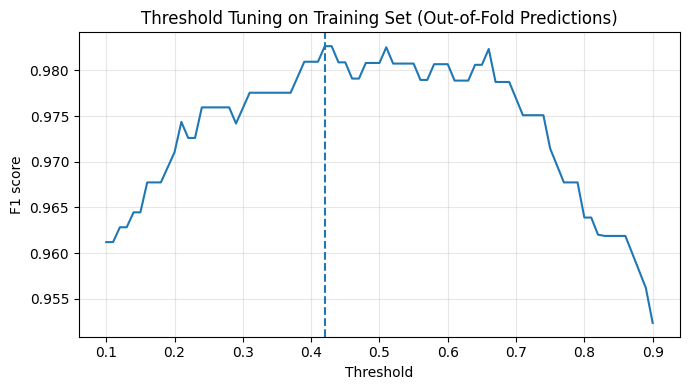

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold Tuning on Training Set (Out-of-Fold Predictions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation
- the threshold is **not always fixed at 0.50**
- different thresholds create different trade-offs
- threshold selection should be done using the **training procedure**, not by peeking at the test set

# 8) Final fit on the full training set

Now that we have:
- chosen the best model
- chosen the threshold using training data only

we can fit the best model on the **full training set**.

In [ ]:
final_model = best_grid.best_estimator_
final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=10, gamma=0.01, probability=True, random_state=42))])

# 9) Final evaluation on the untouched test set

This is the **first time** we use the test set.

In [ ]:
test_scores = final_model.predict_proba(X_test)[:, 1]

y_pred_default = (test_scores >= 0.50).astype(int)
y_pred_tuned = (test_scores >= best_threshold).astype(int)

print("Default threshold (0.50) accuracy:", round(accuracy_score(y_test, y_pred_default), 4))
print("Tuned threshold accuracy:        ", round(accuracy_score(y_test, y_pred_tuned), 4))
print()

print("ROC AUC:", round(roc_auc_score(y_test, test_scores), 4))
print("Average Precision (PR AUC summary):", round(average_precision_score(y_test, test_scores), 4))

Default threshold (0.50) accuracy: 0.9825
Tuned threshold accuracy:         0.9825

ROC AUC: 0.9977
Average Precision (PR AUC summary): 0.9986


## Confusion matrix with tuned threshold

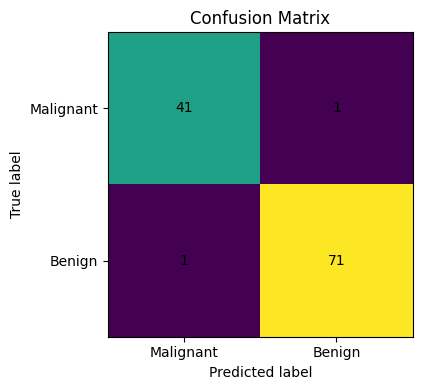

In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)
plot_confusion_matrix_simple(cm, labels=("Malignant", "Benign"))

## Classification report

In [ ]:
print(classification_report(y_test, y_pred_tuned, target_names=["malignant", "benign"]))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## ROC curve
ROC is useful when we want to analyze the trade-off between:
- **True Positive Rate (TPR)** (same as recall)  
$
TPR = \frac{TP}{TP + FN}
$

- **False Positive Rate (FPR)**  
$
FPR = \frac{FP}{FP + TN}
$

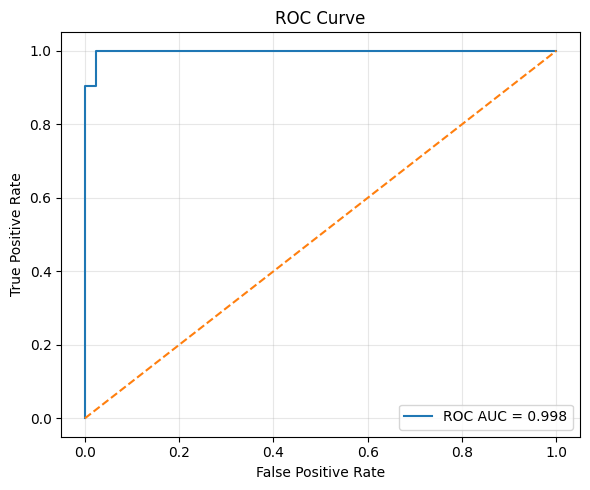

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Precision-Recall curve
PR curves are especially useful when:
- classes are imbalanced
- we care a lot about precision and recall

- **Precision**  
$Precision = \frac{TP}{TP + FP}$

- **Recall**  
$Recall = \frac{TP}{TP + FN}$

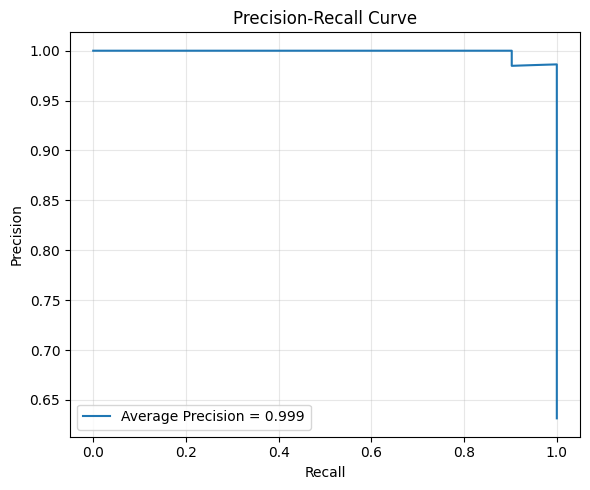

In [ ]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_scores)
ap = average_precision_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10) Take-home questions

1. Why do we split train and test at the beginning?
2. Why is cross-validation done only on the training set?
3. Why can a deeper tree overfit?
4. What do `C` and `gamma` do in SVM?
5. Why is threshold tuning different from model training?
6. Why should we avoid selecting the threshold on the test set?
7. When is ROC more useful? When is PR more useful?

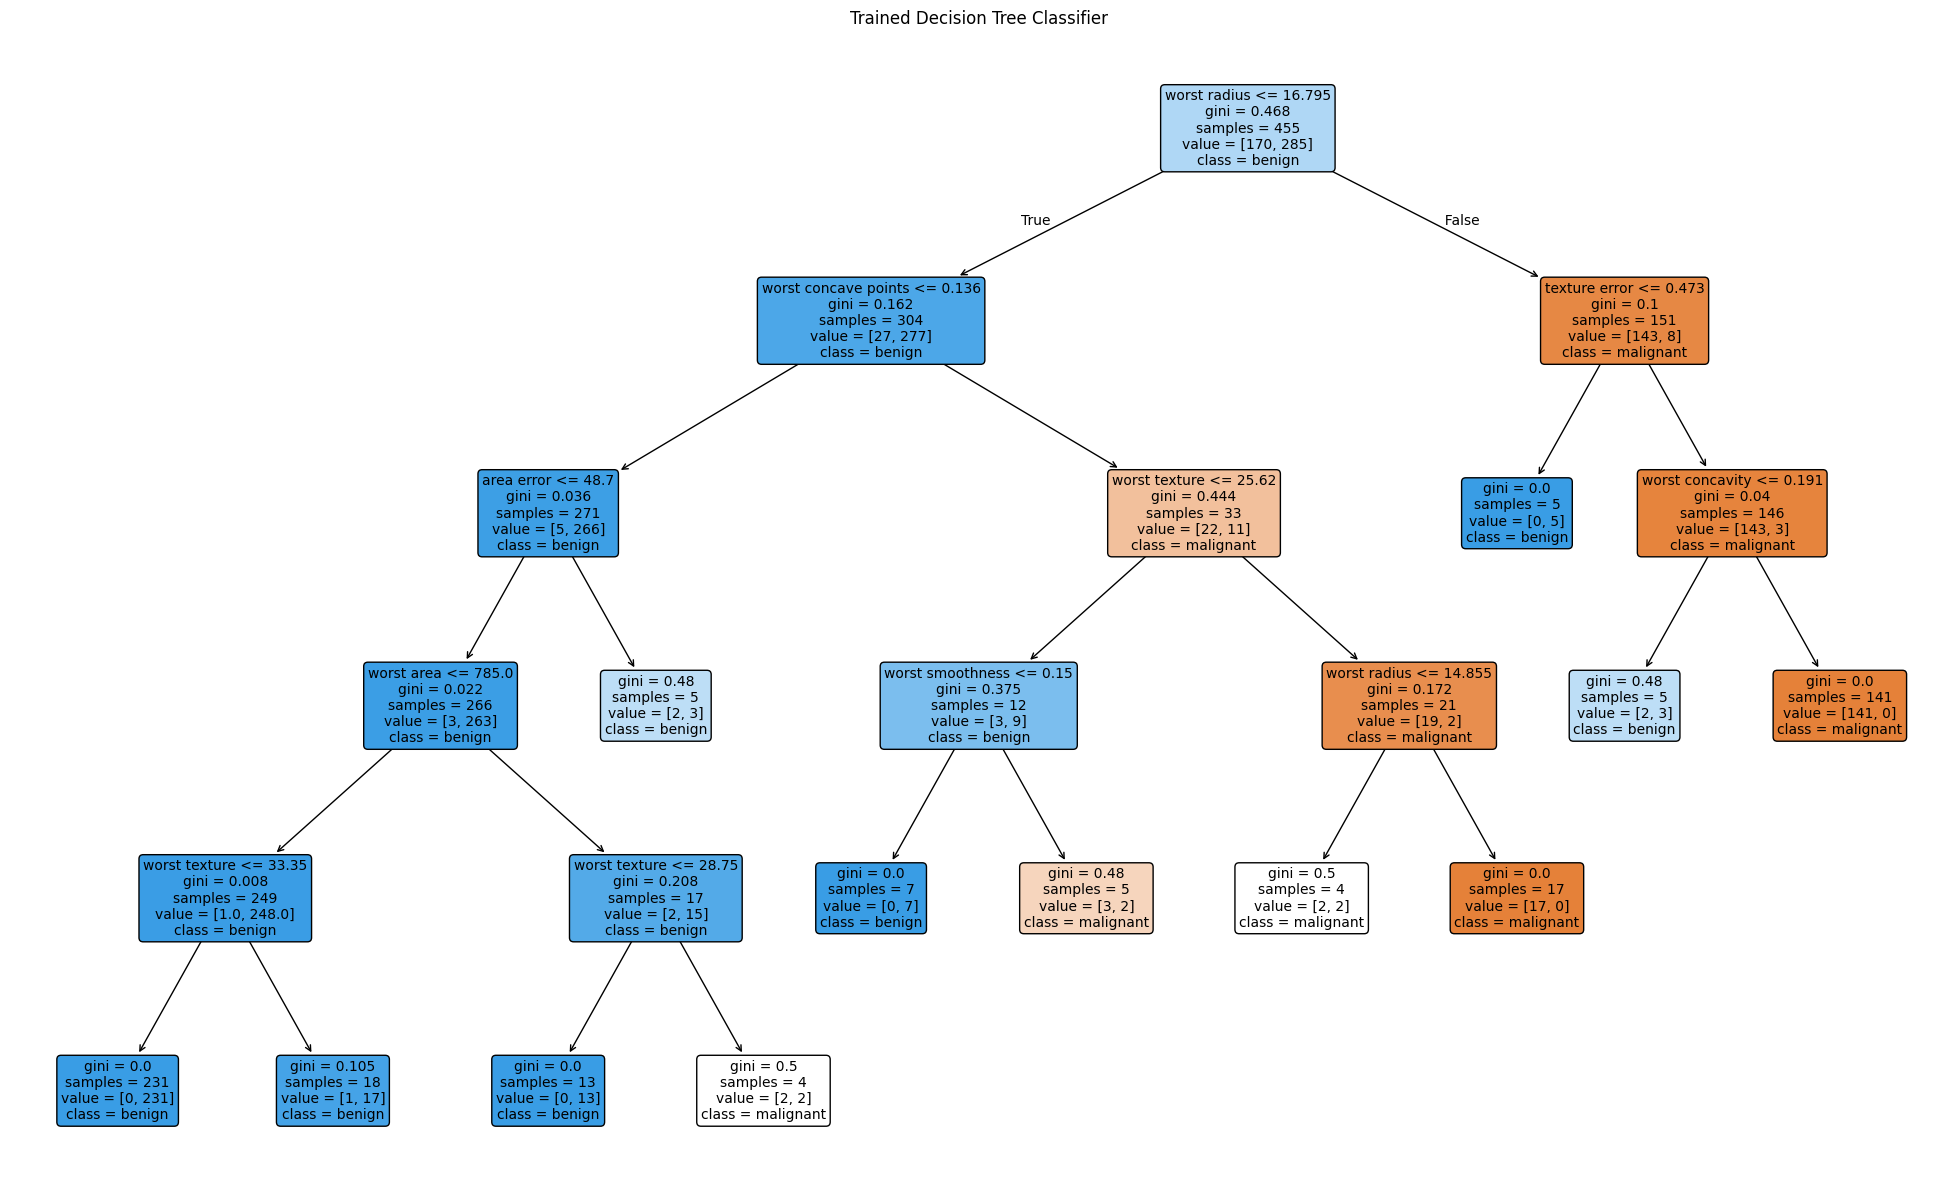

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the best Decision Tree estimator from the grid search
best_tree_model = tree_grid.best_estimator_

plt.figure(figsize=(25, 15))
plot_tree(best_tree_model, filled=True, feature_names=X.columns, class_names=data.target_names, rounded=True, fontsize=10)
plt.title("Trained Decision Tree Classifier")
plt.show()

**Interpretation**
*   top node = most important split

*   follow conditions down the tree

*   leaf node = final prediction

*   gini measures impurity

*   value shows class counts, i.e. [4,2] -> 4 malignant, 2 benign

### Gini

Gini measures **how mixed the classes are in a node** (impurity).

$Gini = 1 - \sum p_i^2$

where $p_i$ is the proportion of class $i$ in the node.

Interpretation:
- **Gini = 0** → node is **pure** (all samples belong to one class)
- **higher Gini** → classes are **more mixed**
- the tree tries to create splits that **reduce Gini impurity**

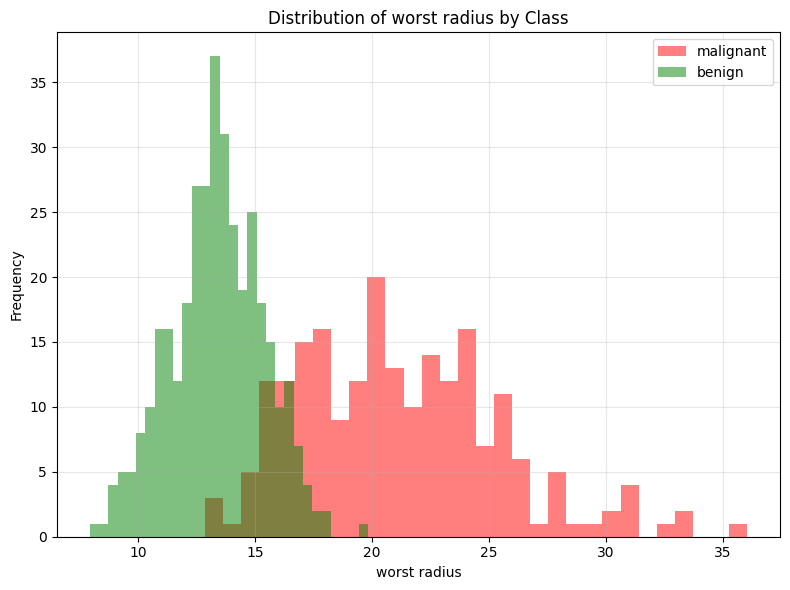

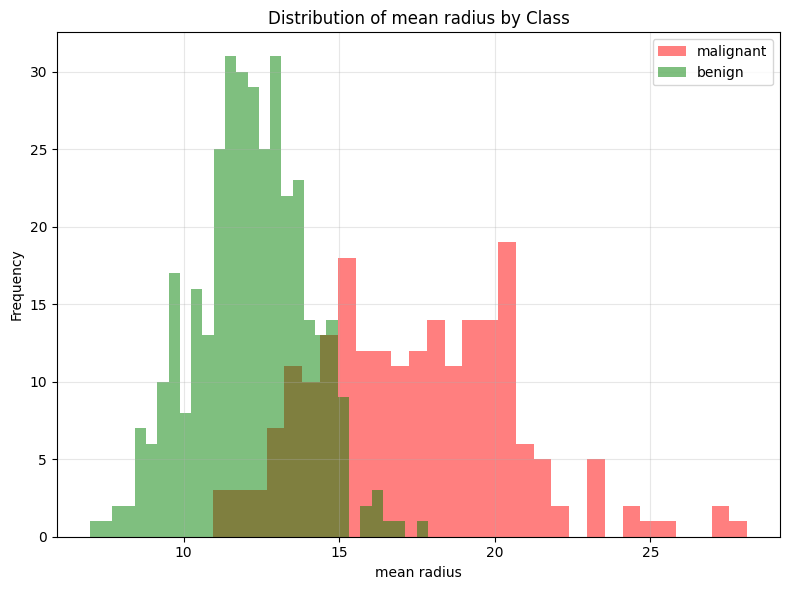

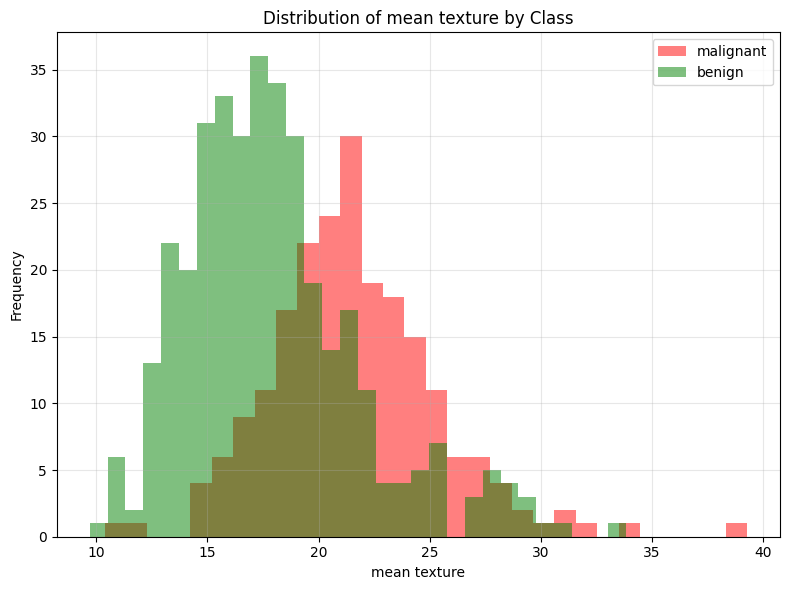

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = pd.concat([X, y], axis=1)

features_to_plot = [
    'worst radius',
    'mean radius',
    'mean texture',
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    plt.hist(
        df_plot[df_plot['target'] == 0][feature],
        alpha=0.5,
        label=data.target_names[0], # Malignant
        bins=30,
        color='red'
    )
    plt.hist(
        df_plot[df_plot['target'] == 1][feature],
        alpha=0.5,
        label=data.target_names[1], # Benign
        bins=30,
        color='green'
    )
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()